In [9]:
import sys
from pathlib import Path

root = Path().resolve()
while root != root.parent:
    if (root / "src").exists():
        if str(root) not in sys.path:
            sys.path.insert(0, str(root))
        break
    root = root.parent

print("Project root added to path:", root)

Project root added to path: /Users/jonathanma/Desktop/MSEnotes/733_NPBayes/FinalProject/NPBS-project-MaZhu


# Data Acquisition

In this project, we study survival analysis in settings where individual patient data (IPD) are not directly available, but Kaplan–Meier (KM) curves and limited summary information are reported.

To develop and evaluate our methods, we simulate trial data and construct the corresponding KM representations that would be observed in practice.

This notebook performs the following steps:
1. Simulate individual-level survival data
2. Construct KM curves and censoring information
3. Extract the quantities used as inputs for IPD reconstruction

In [10]:
from src.simulation.trial_generator import simulate_single_trial

sim = simulate_single_trial(n=300, seed=733, trial_id="trial_001")
df_true = sim.ipd

df_true.head()

,age,biomarker,stage,treatment,time,event,trial_id
0,51.711400,1,1,1,22.536530,1,trial_001
1,66.435730,0,2,1,3.158349,1,trial_001
2,53.794230,0,3,1,11.961035,1,trial_001
3,57.918153,1,2,1,8.838544,0,trial_001
4,72.742596,0,1,0,15.936414,1,trial_001


In [11]:
df_true.describe()
df_true["event"].value_counts()

event
1    233
0     67
Name: count, dtype: int64

In [12]:
# Build KM representation
from src.simulation.km_renderer import build_km_render_from_ipd

render = build_km_render_from_ipd(
    df_true,
    time_col="time",
    event_col="event"
)

curve_points = render.curve_points
censor_points = render.censor_points

curve_points.head()
censor_points.head()

,time,survival,n_censored
0,0.331674,0.986667,1
1,0.459292,0.979977,1
2,1.021834,0.932992,1
3,1.429388,0.902678,1
4,1.515037,0.895917,1


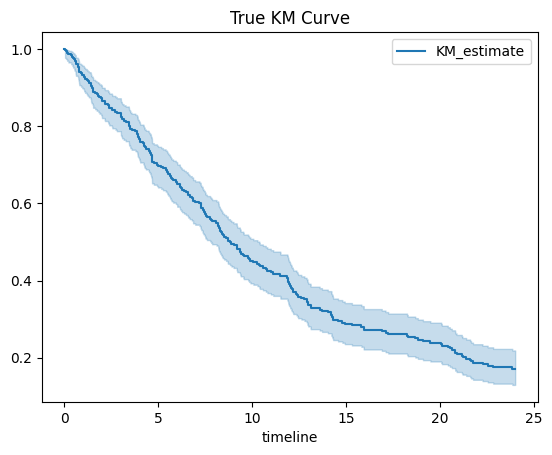

In [13]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(df_true["time"], df_true["event"])

kmf.plot()
plt.title("True KM Curve")
plt.show()

## Observed vs Unobserved Data

In practice, we do not observe individual-level data. Instead, we observe:

- KM step points: (time, survival)
- Censoring times (if available)
- Optional risk tables

The true IPD is unobserved and must be reconstructed.

We now extract the observed inputs used for reconstruction.

In [14]:
# Define reconstruction inputs
t = curve_points["time"].tolist()
S = curve_points["survival"].tolist()
cens_t = censor_points["time"].tolist()

print("Number of KM steps:", len(t))
print("Number of censor points:", len(cens_t))

Number of KM steps: 256
Number of censor points: 22


In [15]:
# Optional multi-trial preview
from src.simulation.trial_generator import simulate_multi_trial

multi = simulate_multi_trial(n_trials=4, n_per_trial=250, seed=733)
df_multi = multi.ipd

df_multi.head()

,age,biomarker,stage,treatment,time,event,trial_id
0,67.106302,1,2,0,1.778858,1,trial_001
1,55.792886,0,2,0,24.000000,0,trial_001
2,55.350177,0,3,0,0.116891,1,trial_001
3,60.424046,1,1,1,0.889068,0,trial_001
4,55.414515,0,1,1,3.516167,1,trial_001


We will later reconstruct and pool across multiple trials, where each trial represents a different population.

In [16]:
from pathlib import Path

# create directories
base = Path("../data")
(base / "raw").mkdir(parents=True, exist_ok=True)
(base / "processed").mkdir(parents=True, exist_ok=True)

# ---- Save TRUE IPD ----
df_true.to_csv(base / "raw" / "simul_data" / "true_ipd_trial_001.csv", index=False)

# ---- Save KM curve inputs ----
curve_points.to_csv(base / "raw" / "simul_data" / "km_curve_points_trial_001.csv", index=False)
censor_points.to_csv(base / "raw" / "simul_data" / "km_censor_points_trial_001.csv", index=False)

# ---- Save reconstruction-ready inputs ----
import json

inputs = {
    "n": int(len(df_true)),
    "t": curve_points["time"].tolist(),
    "S": curve_points["survival"].tolist(),
    "cens_t": censor_points["time"].tolist(),
}

with open(base / "raw" / "simul_data" / "km_inputs_trial_001.json", "w") as f:
    json.dump(inputs, f, indent=2)

print("Saved:")
print("- true IPD")
print("- KM curve points")
print("- censor points")
print("- reconstruction inputs JSON")

Saved:
- true IPD
- KM curve points
- censor points
- reconstruction inputs JSON
